Plotting related to whether model learned in online expoeirment 


In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize
from IPython.display import display
import sys
import os
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np

### SET THIS PATH FROM THE CURRENT WORKING DIRECTORY TO THE REPO DIRECTORY
relative_repo_path = "GitRepos/simulation_closed_loop"

# appedn repo path to sys path
current_path = os.getcwd()
full_repo = os.path.join(current_path,relative_repo_path)
sys.path.append(full_repo)

In [21]:
from openretina.data_io.hoefling_2024.dataloaders import natmov_dataloaders_v2
from  thesis.code.analysis_closed_loop_experiments.utils_model_performance_on_online_data import (bring_pred_target_dict_to_array,
                                                                                                  plot_single_neuron_predicted_actual,
                                                                                                  plot_scatter_correlation,)

In [31]:
data_path_model_performance = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/analysis_closed_loop_experiments/model_performance_on_online_data"

FIGURE_FOLDER = os.path.join(full_repo,"thesis/figures/analysis_closed_loop_experiments")

### load data

In [5]:
# load test,val,train data
with open(os.path.join(data_path_model_performance, "test_corrs.pkl"), "rb") as f:
    test_corrs = pickle.load(f)
with open(os.path.join(data_path_model_performance, "val_corrs.pkl"), "rb") as f:
    val_corrs = pickle.load(f)
with open(os.path.join(data_path_model_performance, "train_corrs.pkl"), "rb") as f:
    train_corrs = pickle.load(f)

# load openretina comparison data
with open(os.path.join(data_path_model_performance,"test_corrs_comparison_sessionsession_1_ventral1_20200226.pkl"), "rb") as f:
    test_corrs_or = pickle.load(f)
with open(os.path.join(data_path_model_performance,"val_corrs_comparison_sessionsession_1_ventral1_20200226.pkl"), "rb") as f:
    val_corrs_or = pickle.load(f)
with open(os.path.join(data_path_model_performance,"train_corrs_comparison_sessionsession_1_ventral1_20200226.pkl"), "rb") as f:
    train_corrs_or = pickle.load(f)


# load pred targets
with open(os.path.join(data_path_model_performance, "test_pred_targets.pkl"), "rb") as f:
    test_pred_targes = pickle.load(f)

with open(os.path.join(data_path_model_performance, "val_pred_targets.pkl"), "rb") as f:
    val_pred_targes = pickle.load(f)  

with open(os.path.join(data_path_model_performance, "train_pred_targets.pkl"), "rb") as f:
    train_pred_targes = pickle.load(f)



### plots

In [6]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/code/plot/plot.py:308: SyntaxWarning: invalid escape sequence '\m'
  txt = txt.replace('^', '}^\mathrm{')
/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/code/plot/plot.py:309: SyntaxWarning: invalid escape sequence '\m'
  txt = txt.replace('_', '}_\mathrm{')
/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/code/plot/plot.py:310: SyntaxWarning: invalid escape sequence '\m'
  txt = txt.replace(' ', '} \mathrm{')
/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/code/plot/plot.py:311: SyntaxWarning: invalid escape sequence '\m'
  txt = txt.replace('-', '\mathrm{-}')


In [ ]:
def plot_all(neuron_pred_targets_dict,axs = None):
    # bring in array format
    model_pred, response = bring_pred_target_dict_to_array(neuron_pred_targets_dict)

    n_neurons = model_pred.shape[0]
    if axs is None:
        fig, axs = plt.subplots(n_neurons,1, figsize=(5,n_neurons * 5))
    
    for neuron_idx in range(n_neurons):
        target_response = response[neuron_idx]
        predicted_response = model_pred[neuron_idx]
        plot_single_neuron_predicted_actual(target_response,predicted_response,ax=axs[neuron_idx])
    

In [28]:
def plot_single(neuron_pred_targets_dict,neuron_idx,axs = None,
                title = None):
    # bring in array format
    model_pred, response = bring_pred_target_dict_to_array(neuron_pred_targets_dict)

    n_neurons = model_pred.shape[0]
    if axs is None:
        fig, axs = plt.subplots(1,1, figsize=(5,5))
    
    target_response = response[neuron_idx]
    predicted_response = model_pred[neuron_idx]
    ax,fig,correl = plot_single_neuron_predicted_actual(target_response,predicted_response,ax=axs,title=title)
    plt.tight_layout()

    return ax,fig,correl


Correlation between actual and predicted: 0.6155
Correlation between actual and predicted: 0.2026
Correlation between actual and predicted: 0.5441
Correlation between actual and predicted: 0.6469
Correlation between actual and predicted: 0.2129
Correlation between actual and predicted: 0.5955
Correlation between actual and predicted: 0.3240


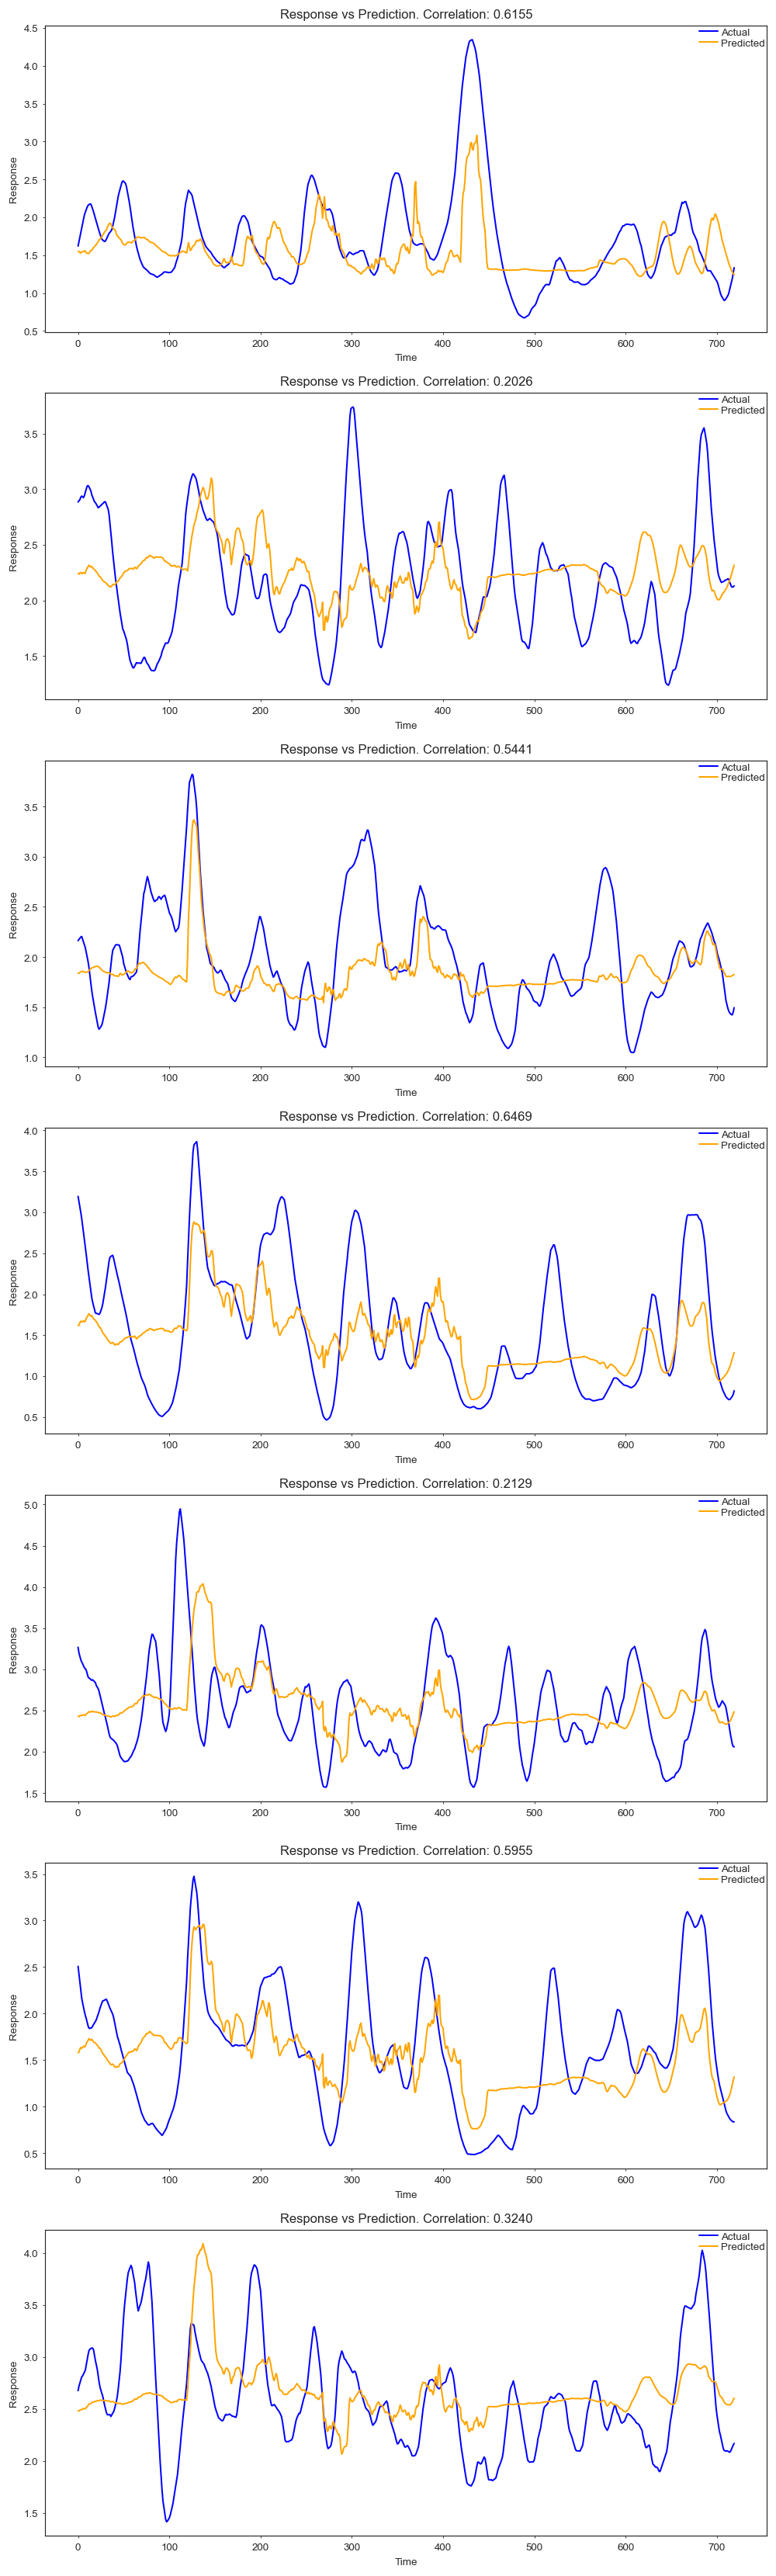

In [8]:
plot_all(neuron_pred_targets_dict = test_pred_targes)

Correlation between actual and predicted: 0.6469


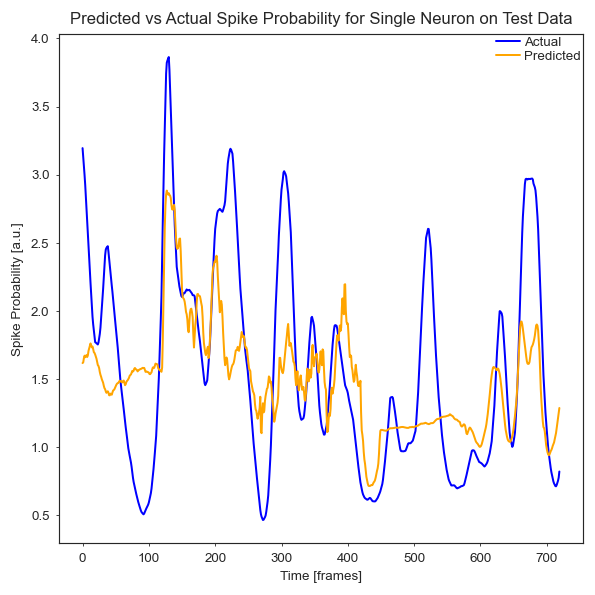

In [32]:
ax,fig,correl = plot_single(neuron_pred_targets_dict = test_pred_targes, neuron_idx=3,title ="Predicted vs Actual Spike Probability for Single Neuron on Test Data")
fig.savefig(os.path.join(FIGURE_FOLDER, 'single_neuron_testset_pred_actual.pdf'), bbox_inches='tight', dpi=600)


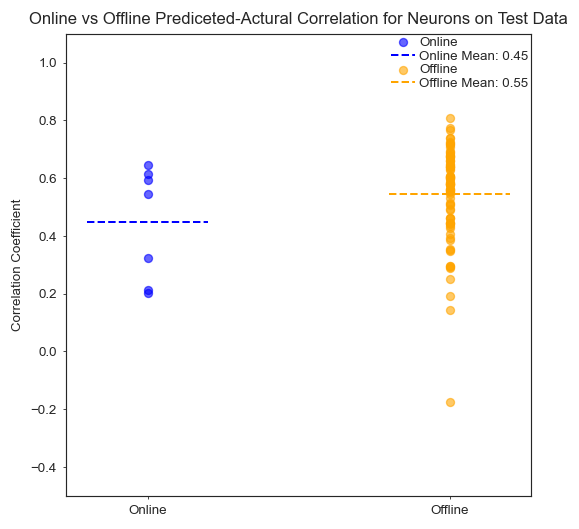

In [34]:
ax, fig = plot_scatter_correlation(online_neuron_correl_dict = test_corrs,
                         offline_neuron_correl_dict = test_corrs_or,
                         title = "Online vs Offline Prediceted-Actural Correlation for Neurons on Test Data")
fig.savefig(os.path.join(FIGURE_FOLDER, 'online_offline_testet_crrel_scatterplot.pdf'), bbox_inches='tight', dpi=600)
